# 신용카드 고객 세그먼트 분류 — 간단 EDA

회원정보(타깃 `Segment` 포함) 중심의 탐색적 분석.
각 코드 셀을 위에서부터 차례로 실행하면 됩니다 (Shift+Enter).

## 1. 셋업 — 라이브러리 / 한글폰트 / 경로

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# Mac 한글 폰트 (한글 컬럼명/라벨 깨짐 방지)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

from pathlib import Path
BASE_DIR = Path("/Users/namgeon-u/Desktop/claude/segment analysis")
print("셋업 완료. BASE_DIR =", BASE_DIR)

셋업 완료. BASE_DIR = /Users/namgeon-u/Desktop/claude/segment analysis


## 2. 회원정보 로드 (201807, 40만 행)

In [2]:
member_path = BASE_DIR / "train" / "1.회원정보" / "201807_train_회원정보.parquet"
df = pd.read_parquet(member_path)

print("shape:", df.shape)
df.head()

shape: (400000, 78)


,기준년월,ID,남녀구분코드,연령,Segment,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,소지카드수_이용가능_신용,입회일자_신용,입회경과개월수_신용,회원여부_연체,이용거절여부_카드론,동의여부_한도증액안내,수신거부여부_TM,수신거부여부_DM,수신거부여부_메일,수신거부여부_SMS,가입통신회사코드,탈회횟수_누적,최종탈회후경과월,탈회횟수_발급6개월이내,탈회횟수_발급1년이내,거주시도명,직장시도명,마케팅동의여부,유효카드수_신용체크,유효카드수_신용,유효카드수_신용_가족,유효카드수_체크,유효카드수_체크_가족,이용가능카드수_신용체크,이용가능카드수_신용,이용가능카드수_신용_가족,이용가능카드수_체크,이용가능카드수_체크_가족,이용카드수_신용체크,이용카드수_신용,이용카드수_신용_가족,이용카드수_체크,이용카드수_체크_가족,이용금액_R3M_신용체크,이용금액_R3M_신용,이용금액_R3M_신용_가족,이용금액_R3M_체크,이용금액_R3M_체크_가족,_1순위카드이용금액,_1순위카드이용건수,_1순위신용체크구분,_2순위카드이용금액,_2순위카드이용건수,_2순위신용체크구분,최종유효년월_신용_이용가능,최종유효년월_신용_이용,최종카드발급일자,보유여부_해외겸용_본인,이용가능여부_해외겸용_본인,이용여부_3M_해외겸용_본인,보유여부_해외겸용_신용_본인,이용가능여부_해외겸용_신용_본인,이용여부_3M_해외겸용_신용_본인,연회비발생카드수_B0M,연회비할인카드수_B0M,기본연회비_B0M,제휴연회비_B0M,할인금액_기본연회비_B0M,할인금액_제휴연회비_B0M,청구금액_기본연회비_B0M,청구금액_제휴연회비_B0M,상품관련면제카드수_B0M,임직원면제카드수_B0M,우수회원면제카드수_B0M,기타면제카드수_B0M,카드신청건수,Life_Stage,최종카드발급경과월
0,201807,TRAIN_000000,2,40대,D,1,1,0,1,1,1,20130101,67,0,0,1,0,0,0,0,L사,1,61,0,0,서울,서울,1,2,1,0,1,0,2,1,0,1,0,1,1,0,0,0,196,196,0,0,0,3681,26,신용,0,0,체크,202110.0,202112.0,20160912.0,0,0,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀성장(2),22
1,201807,TRAIN_000001,1,30대,E,1,1,1,1,1,1,20170801,12,0,0,0,0,0,0,0,K사,1,98,0,0,경기,경기,1,1,1,0,0,0,1,1,0,0,0,1,1,0,0,0,13475,13475,0,0,0,13323,46,신용,0,0,NaN,202112.0,202204.0,20170122.0,0,0,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀성장(1),18
2,201807,TRAIN_000002,1,30대,C,1,1,0,1,1,1,20080401,124,0,0,1,0,0,0,0,S사,1,60,0,0,서울,서울,1,2,1,0,1,0,2,1,0,1,0,1,1,0,0,0,23988,23988,0,0,0,24493,28,신용,0,0,체크,202111.0,202201.0,20161113.0,1,1,0,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,0,자녀출산기,20
3,201807,TRAIN_000003,2,40대,D,1,1,0,1,2,2,20160501,27,0,0,1,0,0,0,0,L사,1,100,0,0,부산,부산,1,3,2,0,1,0,3,2,0,1,0,1,1,0,0,0,3904,3904,0,0,0,5933,1,신용,0,0,체크,202201.0,202111.0,20170205.0,1,1,1,1,1,1,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,1,자녀성장(2),17
4,201807,TRAIN_000004,2,40대,E,1,1,1,1,1,1,20180601,2,0,0,0,0,0,0,0,K사,1,101,0,0,광주,광주,1,2,1,0,1,0,2,1,0,1,0,1,0,0,1,0,1190,0,0,1190,0,0,-2,신용,0,0,체크,202201.0,NaN,20170409.0,1,1,1,0,0,0,0개,0,0,0,0,0,0,0,0개,0개,0개,0개,1,자녀성장(1),15


## 3. 기본 정보 (shape / dtype / 기초통계)

In [3]:
print("=== 행/열 ===", df.shape)
print("\n=== dtype 분포 ===")
print(df.dtypes.value_counts())
print("\n=== 수치형 기초통계 (상위 8개 컬럼) ===")
df.describe().iloc[:, :8]

=== 행/열 === (400000, 78)

=== dtype 분포 ===
int64      61
str        14
float64     3
Name: count, dtype: int64

=== 수치형 기초통계 (상위 8개 컬럼) ===


,기준년월,남녀구분코드,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,소지카드수_유효_신용,소지카드수_이용가능_신용
count,400000.0,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000
mean,201807.0,1.476955,0.957050,0.887640,0.612520,0.992502,1.252465,1.157877
std,0.0,0.499469,0.202745,0.315809,0.487175,0.086263,0.547569,0.612808
min,201807.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,201807.0,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
50%,201807.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,201807.0,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,201807.0,2.000000,1.000000,1.000000,1.000000,1.000000,4.000000,3.000000


## 4. 타깃 `Segment` 분포 (클래스 불균형 확인)

In [4]:
seg_counts = df["Segment"].value_counts().sort_index()
seg_ratio = (df["Segment"].value_counts(normalize=True).sort_index() * 100).round(2)

print("=== Segment 건수 ===")
print(seg_counts)
print("\n=== Segment 비율(%) ===")
print(seg_ratio)
# E가 80%, A/B는 수십~수백건 수준의 극심한 불균형

=== Segment 건수 ===
Segment
A       162
B        24
C     21265
D     58207
E    320342
Name: count, dtype: int64

=== Segment 비율(%) ===
Segment
A     0.04
B     0.01
C     5.32
D    14.55
E    80.09
Name: proportion, dtype: float64


## 5. Segment 분포 시각화

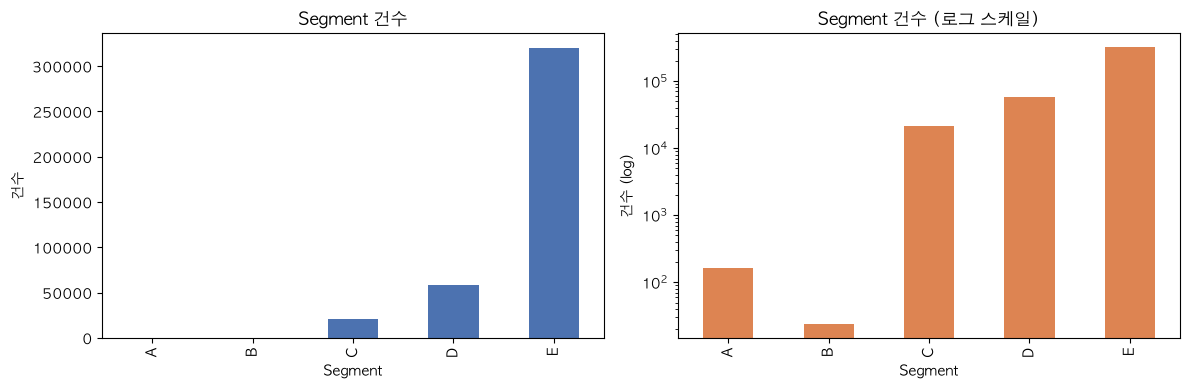

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

seg_counts.plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Segment 건수"); ax[0].set_xlabel("Segment"); ax[0].set_ylabel("건수")

seg_counts.plot(kind="bar", ax=ax[1], color="#DD8452", logy=True)
ax[1].set_title("Segment 건수 (로그 스케일)"); ax[1].set_xlabel("Segment"); ax[1].set_ylabel("건수 (log)")

plt.tight_layout()
plt.show()

## 6. 결측치 점검

In [6]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
na_ratio = (na / len(df) * 100).round(2)

miss = pd.DataFrame({"결측수": na, "결측비율(%)": na_ratio})
print(f"결측 있는 컬럼: {len(miss)} / 전체 {df.shape[1]}")
miss.head(20)

결측 있는 컬럼: 7 / 전체 78


,결측수,결측비율(%)
_2순위신용체크구분,157866,39.47
최종유효년월_신용_이용,79318,19.83
가입통신회사코드,67364,16.84
직장시도명,40807,10.20
최종유효년월_신용_이용가능,32828,8.21
최종카드발급일자,3007,0.75
_1순위신용체크구분,2147,0.54


## 7. 연령 / 성별 분포

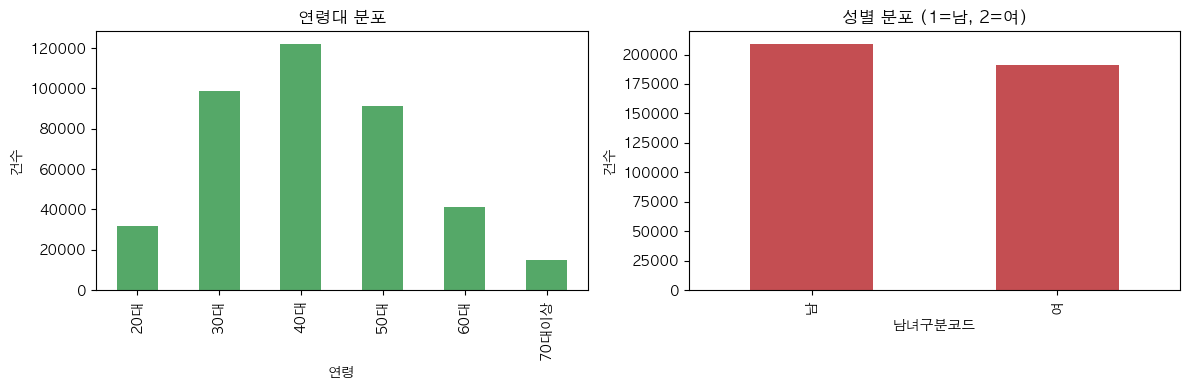

In [7]:
age_order = ["20대", "30대", "40대", "50대", "60대", "70대이상"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["연령"].value_counts().reindex(age_order).plot(kind="bar", ax=ax[0], color="#55A868")
ax[0].set_title("연령대 분포"); ax[0].set_ylabel("건수")

df["남녀구분코드"].map({1: "남", 2: "여"}).value_counts().plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("성별 분포 (1=남, 2=여)"); ax[1].set_ylabel("건수")

plt.tight_layout()
plt.show()

## 8. 연령대 × Segment 교차분석

=== 연령대별 Segment 비율(%) ===
Segment    A    B    C     D     E
연령                                
20대      0.0  0.0  2.2  13.5  84.3
30대      0.0  0.0  5.4  17.3  77.3
40대      0.0  0.0  6.6  15.8  77.5
50대      0.1  0.0  5.4  13.0  81.5
60대      0.0  0.0  4.0  10.8  85.1
70대이상    0.0  0.0  3.6   8.6  87.8


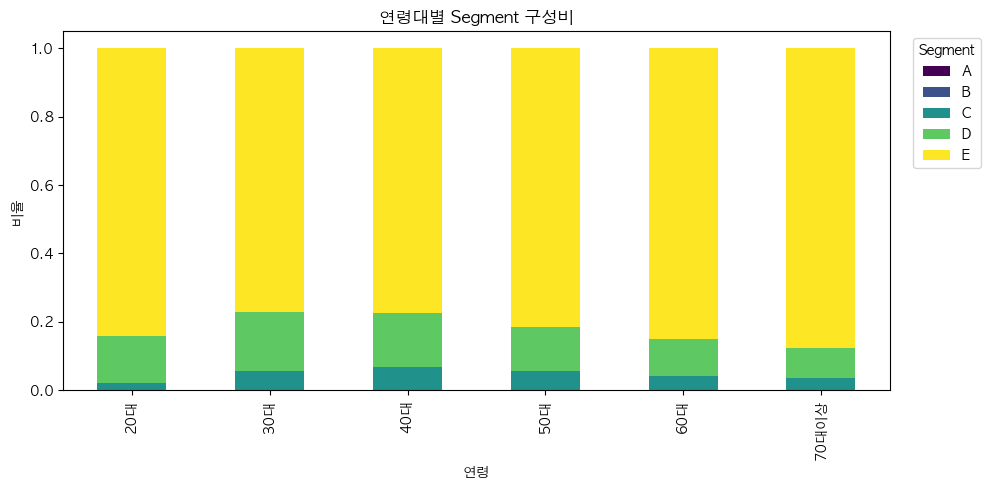

In [8]:
ct = pd.crosstab(df["연령"], df["Segment"], normalize="index").reindex(age_order)
print("=== 연령대별 Segment 비율(%) ===")
print((ct * 100).round(1))

ct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("연령대별 Segment 구성비"); plt.ylabel("비율")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. 신용정보 조인 — Segment별 카드한도 비교

=== Segment별 카드이용한도금액 ===
             mean    median   count
Segment                            
A        198134.0  200516.0     162
B        124868.0   88422.0      24
C         97981.0   86322.0   21265
D         69515.0   51946.0   58207
E         45801.0   41396.0  320342


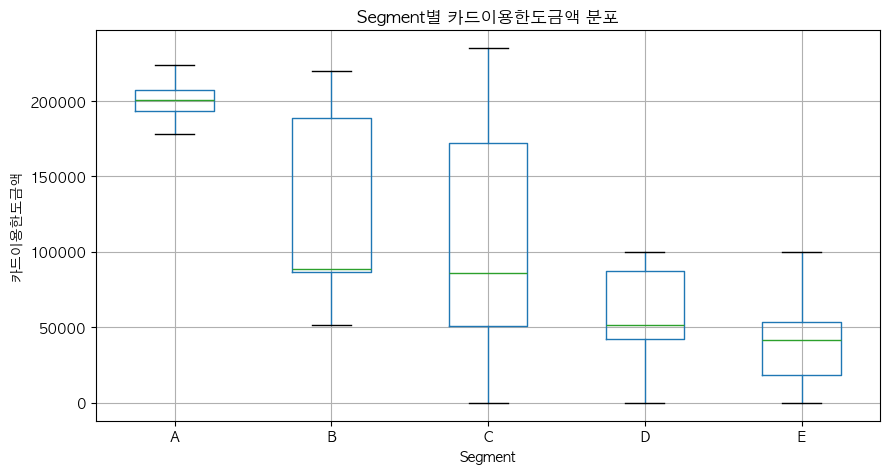

In [9]:
credit_path = BASE_DIR / "train" / "2.신용정보" / "201807_train_신용정보.parquet"
credit = pd.read_parquet(credit_path, columns=["ID", "기준년월", "카드이용한도금액"])

merged = df[["ID", "기준년월", "Segment"]].merge(credit, on=["ID", "기준년월"], how="left")
limit_by_seg = merged.groupby("Segment")["카드이용한도금액"].agg(["mean", "median", "count"])
print("=== Segment별 카드이용한도금액 ===")
print(limit_by_seg.round(0))

merged.boxplot(column="카드이용한도금액", by="Segment", figsize=(9, 5), showfliers=False)
plt.title("Segment별 카드이용한도금액 분포"); plt.suptitle(""); plt.ylabel("카드이용한도금액")
plt.tight_layout()
plt.show()

## 10. (유틸) 6개월 전체 합치는 함수

In [10]:
def load_all_months(category_dir: str, columns=None) -> pd.DataFrame:
    """카테고리 폴더 안의 월별 parquet를 모두 읽어 세로로 합침."""
    folder = BASE_DIR / "train" / category_dir
    files = sorted(folder.glob("*.parquet"))
    parts = [pd.read_parquet(f, columns=columns) for f in files]
    out = pd.concat(parts, ignore_index=True)
    print(f"{category_dir}: {len(files)}개월 → shape {out.shape}")
    return out

# 사용 예:
# member_all = load_all_months("1.회원정보", columns=["ID", "기준년월", "연령", "Segment"])
# member_all.groupby("기준년월")["Segment"].value_counts().unstack()